 ## Gustavo Calin dos Santos 17.01190-6

## Importação de bibliotecas e classes

In [16]:
import numpy as np    # Operações numéricas em geral
import pandas as pd   # Leitura de dados e operações em DataFrames
from matplotlib import pyplot as plt    # Geração de gráficos

from sklearn.linear_model import LinearRegression   # Regressão linear

## **2)** Leitura de dados e exploração inicial

In [17]:
# Antes de executar essa célula é preciso
# 1) "Montar" o disco
# 2) Ajustar o caminho do arquivo

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Ciência de Dados e Inteligência Artificial/Aprendizado de Maquina/Datasets/sao-paulo-properties-april-2019.csv')
df.head()
#display(df)

,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool,New,District,Negotiation Type,Property Type,Latitude,Longitude
0,930,220,47,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.543138,-46.479486
1,1000,148,45,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.550239,-46.480718
2,1000,100,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.542818,-46.485665
3,1000,200,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.547171,-46.483014
4,1300,410,55,2,2,1,1,1,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.525025,-46.482436


### **2.1)** Características gerais

In [18]:
# Dimensões do DataFrame
df.shape

(13640, 16)

In [19]:
# Nomes das colunas
df.columns

Index(['Price', 'Condo', 'Size', 'Rooms', 'Toilets', 'Suites', 'Parking',
       'Elevator', 'Furnished', 'Swimming Pool', 'New', 'District',
       'Negotiation Type', 'Property Type', 'Latitude', 'Longitude'],
      dtype='object')

Fazer a classificação para os bairros (district)

In [20]:
# Análise das correlações lineares
# Critério: |r| entre 0 e 0,4: fraca
#           |r| acima de 0,4 e abaixo de 0,7: moderada
#           |r| maior ou igual a 0,7: forte
df.corr(numeric_only = True)

,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool,New,Latitude,Longitude
Price,1.000000,0.203857,0.378450,0.272267,0.341887,0.313267,0.337959,0.102495,-0.006385,0.131494,0.033812,-0.021678,-0.024897
Condo,0.203857,1.000000,0.761019,0.451355,0.543094,0.535896,0.632137,0.000779,0.101748,0.157123,-0.082479,-0.029288,-0.032258
Size,0.378450,0.761019,1.000000,0.663280,0.684416,0.675828,0.741757,0.012513,0.033325,0.130841,-0.046182,-0.035356,-0.038486
Rooms,0.272267,0.451355,0.663280,1.000000,0.554324,0.527250,0.589587,0.035810,-0.054274,0.161721,-0.010999,-0.049751,-0.051009
Toilets,0.341887,0.543094,0.684416,0.554324,1.000000,0.910445,0.694664,0.178360,0.078729,0.263564,-0.028709,-0.135492,-0.137089
Suites,0.313267,0.535896,0.675828,0.527250,0.910445,1.000000,0.704515,0.140794,0.072325,0.266896,-0.040307,-0.138138,-0.139654
Parking,0.337959,0.632137,0.741757,0.589587,0.694664,0.704515,1.000000,0.053850,0.080594,0.293948,-0.024046,-0.060613,-0.062953
Elevator,0.102495,0.000779,0.012513,0.035810,0.178360,0.140794,0.053850,1.000000,0.066680,0.204461,0.170077,-0.127179,-0.121063
Furnished,-0.006385,0.101748,0.033325,-0.054274,0.078729,0.072325,0.080594,0.066680,1.000000,0.146984,-0.045555,-0.018098,-0.016798
Swimming Pool,0.131494,0.157123,0.130841,0.161721,0.263564,0.266896,0.293948,0.204461,0.146984,1.000000,0.006989,-0.038082,-0.035105


In [21]:
# Codificação one hot das origens dos automoveis
df.describe()

,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool,New,Latitude,Longitude
count,1.364000e+04,13640.000000,13640.000000,13640.000000,13640.000000,13640.000000,13640.000000,13640.000000,13640.000000,13640.00000,13640.000000,13640.000000,13640.000000
mean,2.877378e+05,689.882331,84.373900,2.312023,2.073680,0.980792,1.393182,0.354179,0.146774,0.51217,0.015616,-22.077047,-43.597088
std,5.908214e+05,757.649363,58.435676,0.777461,0.961803,0.834891,0.829932,0.478281,0.353894,0.49987,0.123988,5.866633,11.487288
min,4.800000e+02,0.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,-46.749039,-58.364352
25%,1.858750e+03,290.000000,50.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000,-23.594552,-46.681671
50%,8.100000e+03,500.000000,65.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.00000,0.000000,-23.552813,-46.637255
75%,3.600000e+05,835.000000,94.000000,3.000000,2.000000,1.000000,2.000000,1.000000,0.000000,1.00000,0.000000,-23.517640,-46.560040
max,1.000000e+07,9500.000000,880.000000,10.000000,8.000000,6.000000,9.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.000000


In [22]:
df['District'].value_counts()

,count
District,
Moema/São Paulo,293
Mooca/São Paulo,288
Brás/São Paulo,255
Brooklin/São Paulo,250
Bela Vista/São Paulo,250
...,...
São Rafael/São Paulo,44
Jardim São Luis/São Paulo,44
Grajaú/São Paulo,37


In [23]:
df['Property Type'].value_counts()

,count
Property Type,
apartment,13640


In [24]:
df['Negotiation Type'].value_counts()

,count
Negotiation Type,
rent,7228
sale,6412


## Remover as linhas de apartamento que estão a venda

In [25]:
# Remover as linhas de apartamentos com tipo de negociacao venda
df = df[~((df['Property Type'] == 'apartment') & (df['Negotiation Type'] == 'sale'))]

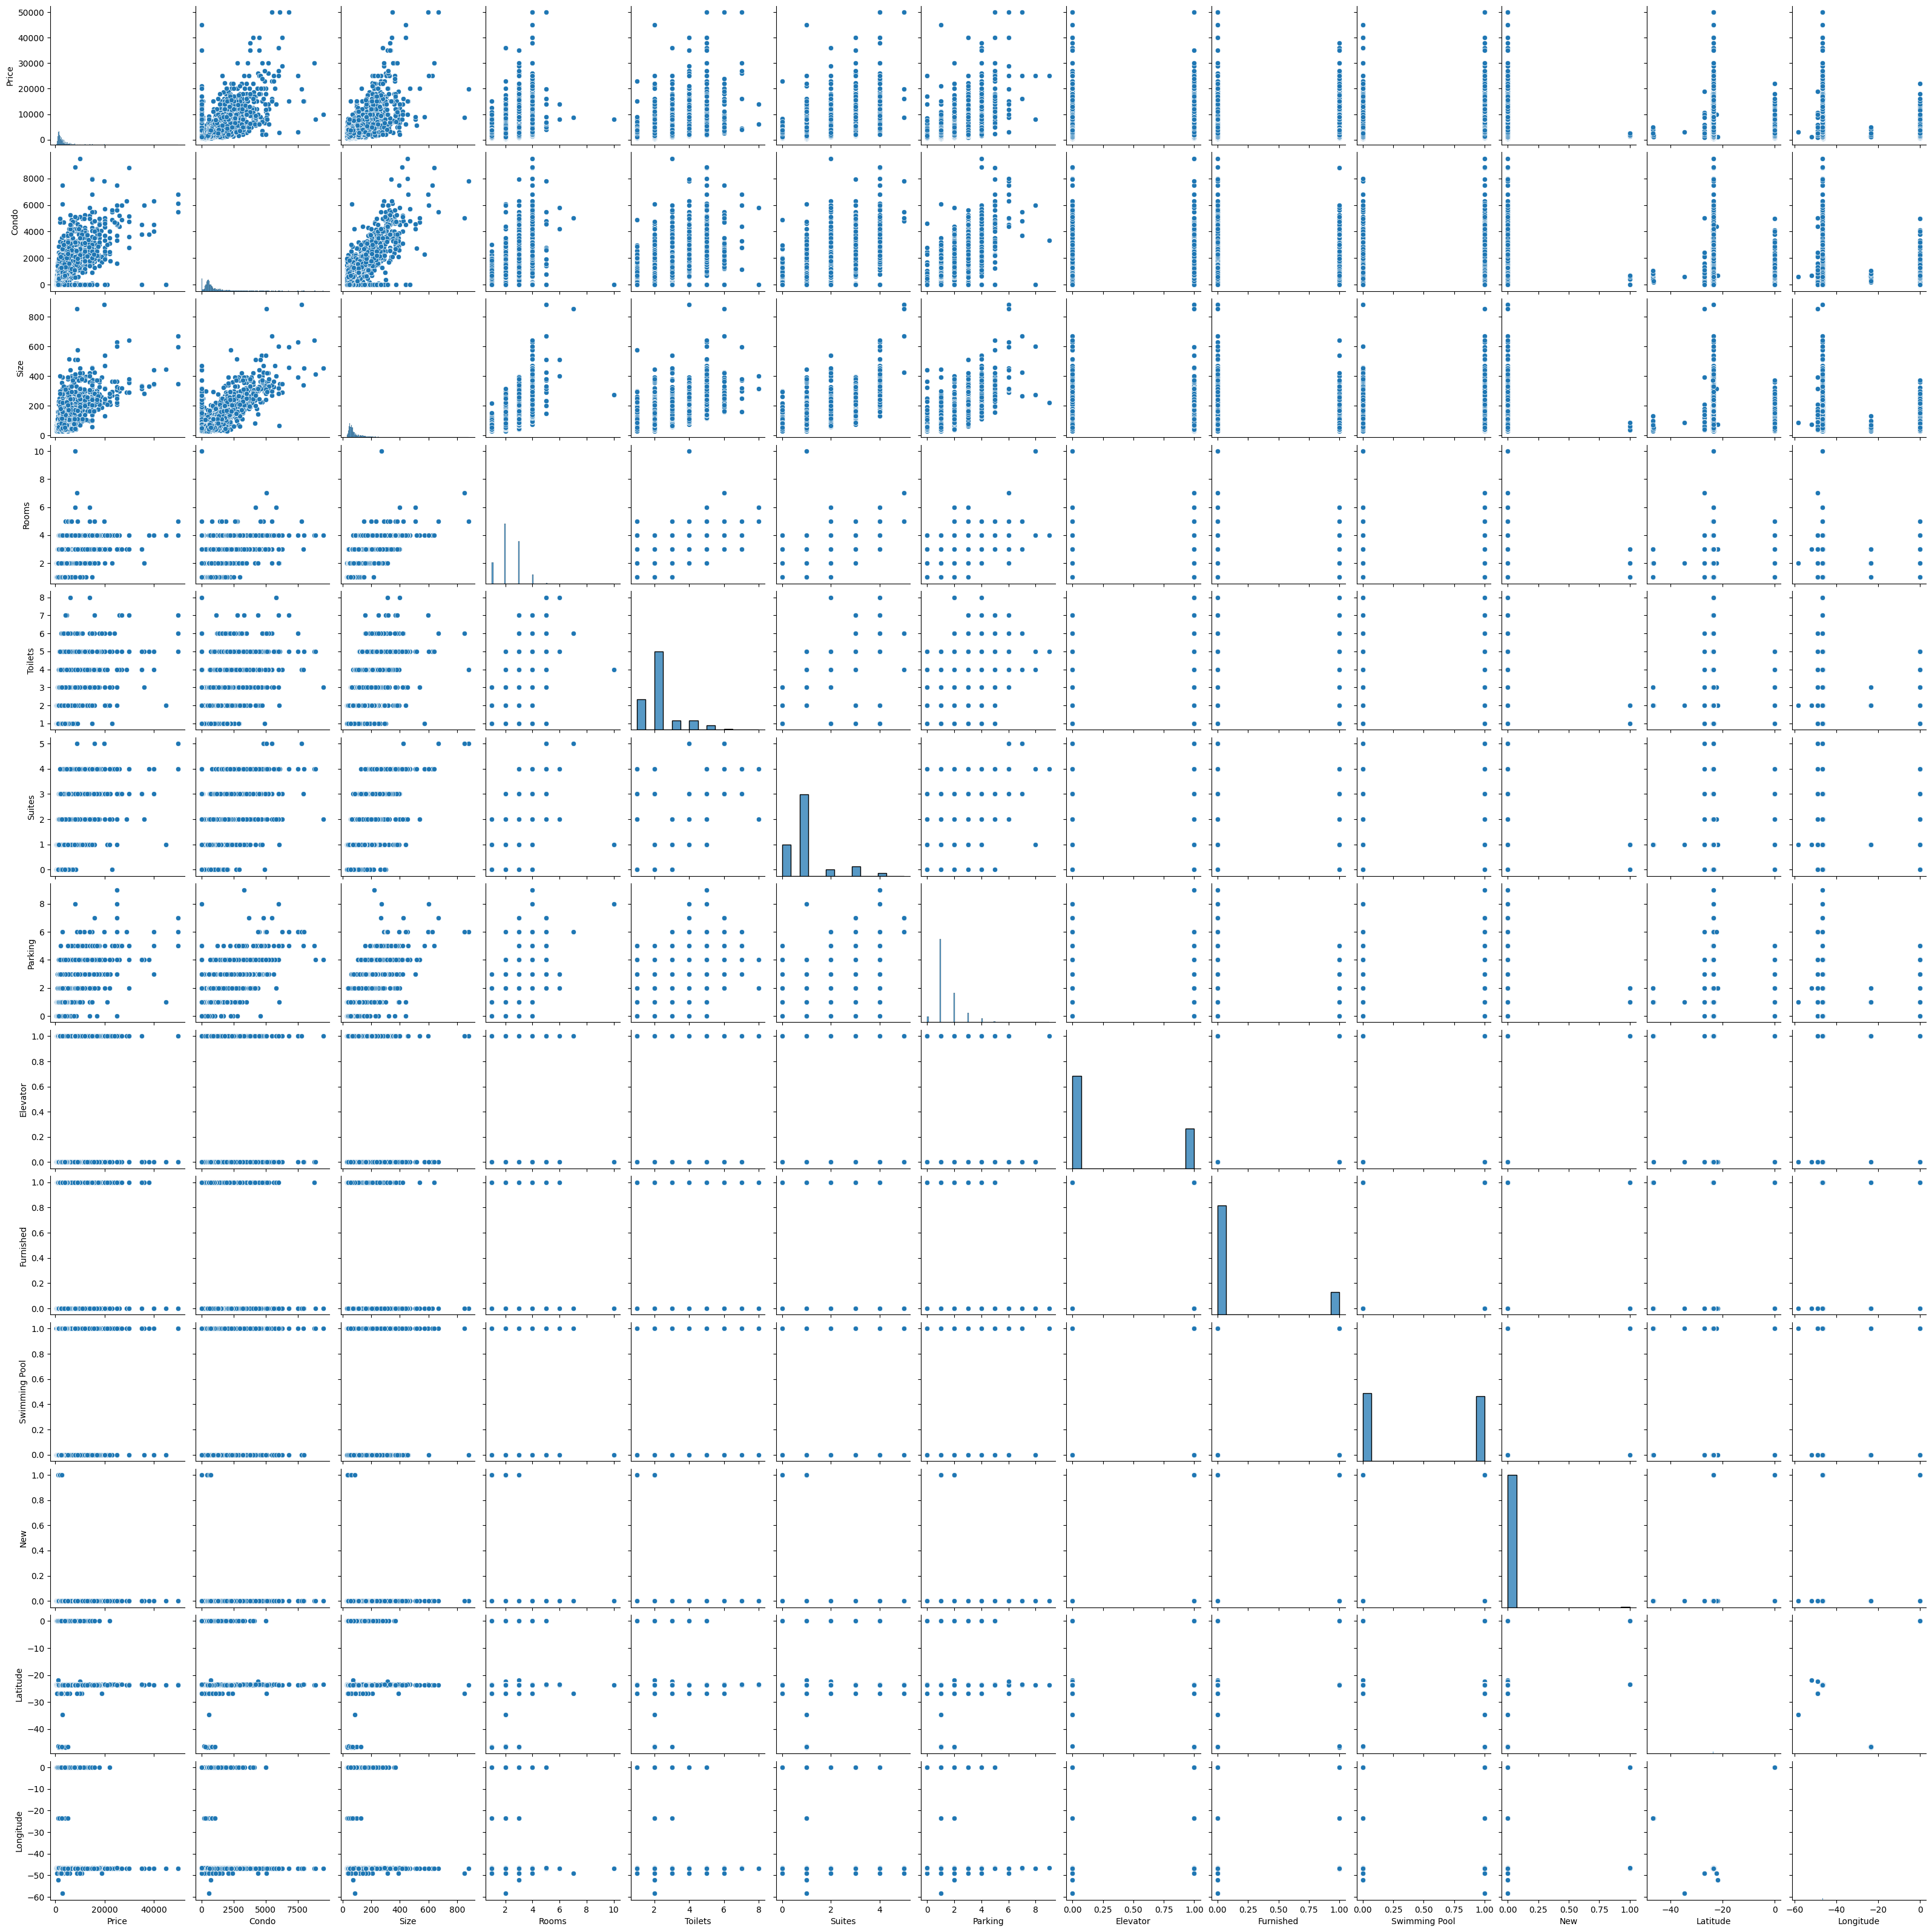

In [26]:
import seaborn as sns
sns.pairplot(df)
plt.show()

## **3)** Pré-processamanto e Seleção de variáveis

In [27]:
# Codificação one hot do Bairros
df = pd.get_dummies(df, columns = ['District'], dtype = int, drop_first = True)
df.head()

,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool,...,District_Vila Jacuí/São Paulo,District_Vila Leopoldina/São Paulo,District_Vila Madalena/São Paulo,District_Vila Maria/São Paulo,District_Vila Mariana/São Paulo,District_Vila Matilde/São Paulo,District_Vila Olimpia/São Paulo,District_Vila Prudente/São Paulo,District_Vila Sônia/São Paulo,District_Água Rasa/São Paulo
0,930,220,47,2,2,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1000,148,45,2,2,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1000,100,48,2,2,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1000,200,48,2,2,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1300,410,55,2,2,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
y = df['Price']  # Variável dependente (mpg) comumo milhas por galão
X = df.drop(columns= ['Price', 'Negotiation Type', 'Property Type', 'Latitude', 'Longitude']) # Variaveis independentes

In [29]:
reg = LinearRegression() # Cria objeto de modelo liniar
reg.fit(X,y)             # Treina o modelo usando todos os dados

LinearRegression()

In [30]:
# Coeficientes
print("Intercepto = ",reg.intercept_)
print("Coeficientes angulares = ",reg.coef_)

Intercepto =  1493.020944485059
Coeficientes angulares =  [ 2.39546917e-01  2.82872399e+01 -4.87527430e+02  9.98583260e+01
  2.56449992e+02  6.87730618e+02 -7.27969592e+01  6.88530573e+02
  2.47193599e+02  4.14613610e+02 -1.66268077e+03 -2.04984403e+03
 -2.10186362e+03 -1.29599209e+03 -1.53971333e+03 -2.09111236e+03
 -2.47494649e+03 -2.09891320e+03  1.53075880e+02 -1.60667342e+03
 -2.19267051e+03 -2.30419544e+03 -1.85904691e+03 -5.78406292e+02
 -1.99007214e+03 -2.20854244e+03 -2.00549980e+03 -2.06308257e+03
 -2.44502743e+03 -2.09942482e+03 -2.17664826e+03 -3.41769075e+03
 -2.18298176e+03 -1.74243145e+03 -4.08030725e+02 -2.19216157e+03
 -2.10128787e+03 -2.19043008e+03 -2.43690977e+03 -1.85911234e+03
  2.94532892e+03 -2.03076535e+03  1.84239904e+03 -2.11481053e+03
 -1.95380936e+03 -2.04025589e+03 -2.08570836e+03 -2.10400640e+03
 -2.28813883e+03 -1.73678245e+02 -2.06054611e+03 -2.12856156e+03
 -2.65265153e+03 -2.15543971e+03 -2.14306002e+03 -1.87750782e+03
 -1.65947857e+03 -1.91414837e+03

In [31]:
# Função para o cálculo do coeficiente de determinação da regressão
# linear simples (R^2) ou múltipla (R^2 ajustado):

def R2_R2ajust(regressor,X,y):
  R2 = regressor.score(X,y)  # R^2
  n = len(y)      # Quantidade de dados de treino
  m = X.shape[1]  # Quantidade de variáveis independentes do modelo
  if m == 1:
    return R2   # Regressão simples: retorna R^2
  else:
    return 1-((n-1)/(n-m-1))*(1-R2)  # Regressão múltipla: R^2 ajustado

In [32]:
# Qualidade do ajuste
print('R^2 = ', R2_R2ajust(reg,X,y))

R^2 =  0.6910306002447963


In [33]:
# Separação dos dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split

# Parâmetros da função 'train_test_split':
# X,y = arrays (ou equivalentes) das variáveis independentes (X) e dependente (y)
# train_size/test_size = percentual de dados de treino/teste. Padrão: 75% (treino) e 25% (teste)

# Divide os dados: 80% para treino ('train_size'), 20% para teste
# IMPORTANTE: sem o controle do parâmetro 'random_state', diferentes partições
# do conjunto de dados serão retornadas a cada execução do método de divisão
X_treino, X_teste, y_treino, y_teste = train_test_split(X,y,train_size = 0.8, random_state = 42)

print("Dimensões dos dados de treino:",X_treino.shape)
print("Dimensões dos dados de teste:",X_teste.shape)

Dimensões dos dados de treino: (5782, 103)
Dimensões dos dados de teste: (1446, 103)


In [34]:
# Treinamento do modelo (apenas) com os dados de treino (80% do total)
reg_treino = LinearRegression()
reg_treino.fit(X_treino,y_treino)

LinearRegression()

In [35]:
# Qualidade do ajuste
print("Coeficiente de determinação AJUSTADO =",R2_R2ajust(reg_treino,X_treino,y_treino))

Coeficiente de determinação AJUSTADO = 0.6922554743412135


In [36]:
# Erros de previsão
# RMSE e MAPE do modelo para os dados de teste

# Cálculo das previsões
y_prev_teste = reg_treino.predict(X_teste)

from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

# Principais parâmetros das funções 'root_mean_squared_error' e
# 'mean_absolute_percentage_error':
# y_true = valores reais da variável dependente (y)
# y_pred = valores previstos pelo modelo para a variável dependente

RMSE = root_mean_squared_error(y_true = y_teste,y_pred = y_prev_teste)
MAPE = mean_absolute_percentage_error(y_true = y_teste,y_pred = y_prev_teste)
print("RMSE para os dados de teste =",RMSE)
print("MAPE para os dados de teste =",MAPE)

RMSE para os dados de teste = 2118.2656140128556
MAPE para os dados de teste = 0.36074591286568014


In [37]:
from sklearn.model_selection import cross_val_score

# Parâmetros da função 'cross_val_score':
# estimator = um estimador (neste caso, um objeto da classe 'LinearRegression')
# X,y = arrays (ou equivalentes) das variáveis independentes (X) e dependente (y)
# scoring = texto indicativo da métrica de qualidade a ser calculada
# cv = número [inteiro] de partições (k); valor padrão: k = 5

# Executa a validação cruzada k-folds, com k = 10, avaliando a métrica RMSE
aval = cross_val_score(reg,X,y,cv = 10,scoring = 'neg_root_mean_squared_error')

# Calcula o coeficiente de variação das avaliações = desvio padrão/média
# Critério para o coeficiente de variação:
# Até 20%: variação baixa
# De 20% a 60%: variação moderada
# Acima de 60%: variação alta
M = np.mean(-aval)            # Média das avaliações
DP = np.std(-aval,ddof = 1)   # Desvio padrão (amostral) das avaliações
CV_aval = 100*DP/M            # Coeficiente de variação (%) das avaliações

print("Valores de RMSE obtidos:",-aval)   # Obs: troca o sinal dos valores
print("")   # "Imprime" uma linha em branco
print("RMSE médio =",M)
print("Coeficiente de variação (%) =",CV_aval)

Valores de RMSE obtidos: [1626.28406244 2390.665002   1618.39698903 1518.11483388 1759.99274616
 3271.74428711 1733.02768179 1412.86800759 1633.65763969 2344.67165178]

RMSE médio = 1930.9422901470869
Coeficiente de variação (%) = 29.73185079378727


In [38]:
# Executa a validação cruzada, avaliando a métrica MAPE
aval = cross_val_score(reg,X,y,cv = 10,scoring = 'neg_mean_absolute_percentage_error')

# Calcula o coeficiente de variação das avaliações = desvio padrão/média
# Critério para o coeficiente de variação:
# Até 20%: variação baixa
# De 20% a 60%: variação moderada
# Acima de 60%: variação alta
M = np.mean(-aval)            # Média das avaliações
DP = np.std(-aval,ddof = 1)   # Desvio padrão (amostral) das avaliações
CV_aval = 100*DP/M            # Coeficiente de variação (%) das avaliações

print("Valores de MAPE obtidos:",-aval)   # Obs: troca o sinal dos valores
print("")   # "Imprime" uma linha em branco
print("MAPE médio =",M)
print("Coeficiente de variação (%) =",CV_aval)

Valores de MAPE obtidos: [0.38951246 0.37135987 0.31671231 0.41504581 0.3939473  0.39289252
 0.30304172 0.43253607 0.34074077 0.38962269]

MAPE médio = 0.37454115268696836
Coeficiente de variação (%) = 11.17903338301733


In [42]:
# Previsão
y_prev = reg_treino.predict(X_teste)
print("Previsão para os apartamento de teste:",y_prev)
print("Valores reais dos apartamentos de teste:",y_teste)

Previsão para os apartamento de teste: [ 851.54826573 1363.50510051 1392.67511028 ...  156.4001249  3755.41814684
 1511.23029073]
Valores reais dos apartamentos de teste: 2020     1399
10852    2000
3043     2000
9391     1300
1383     1600
         ... 
4303     1100
9597     1300
3340     2000
5171     5000
9142     1700
Name: Price, Length: 1446, dtype: int64


In [45]:
dados = {
    'y_real': y_teste,
    'y_previsto': y_prev
}
df = pd.DataFrame(dados)
print(df)

       y_real   y_previsto
2020     1399   851.548266
10852    2000  1363.505101
3043     2000  1392.675110
9391     1300   821.287497
1383     1600  2580.887100
...       ...          ...
4303     1100  1905.091948
9597     1300   826.799266
3340     2000   156.400125
5171     5000  3755.418147
9142     1700  1511.230291

[1446 rows x 2 columns]
